# Jordan Lake Spatiotemporal Simulation
ASV wind characterization simulation at the Jordan Lake mission domain.

Features:
- STGPKF Formulation
    - Generate Synthetic Data
    - Make estimates based upon existing measurements
- Ergodic Control
- Real-Time SOC-Based speed control
- Known Hyperparameters

In [57]:
# Import Packages
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

using LinearAlgebra
using Random
using Statistics
using Plots
using LaTeXStrings
using Revise
using StaticArrays
using Interpolations
using LazySets
using SpatiotemporalGPs
using JLD2
using LinearInterpolations
using DifferentialEquations
using ForwardDiff
using LinearAlgebra, StatsBase

In [58]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")
include("../src/transects.jl")

┌ Warning: Replacing docs for Main.Variograms.hp_fit :: Tuple{Any} in module
│ Main.Variograms
└ @ Base.Docs docs/Docs.jl:243


Main.Transects

# Synthetic Data

In [59]:
# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours
ts_min = T_begin*60:dt_min:T_end*60

540.0:0.041666666666666664:720.0

In [60]:
# setup the spatial and temporal kernels
σt = 1.0   # m/s
σs = 1.0   # m/s
lt = 0.75*60.0  # minutes
ls = 0.75   # km

kt = Matern(1/2, σt, lt)
ks = Matern(1/2, σs, ls)

# Create spatial domain
# determine the spatial step size
dx = 0.05 # km

# create the spatial domain
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);

In [61]:
# generate synthetic data
synthetic_data = STGPKF.generate_spatiotemporal_process(xs, ys, dt_min, (T_end-T_begin)*60, ks, kt);

[ Info: Saved animation to /tmp/jl_4fQnCv8N0h.gif


Plots.AnimatedGif("/tmp/jl_4fQnCv8N0h.gif")
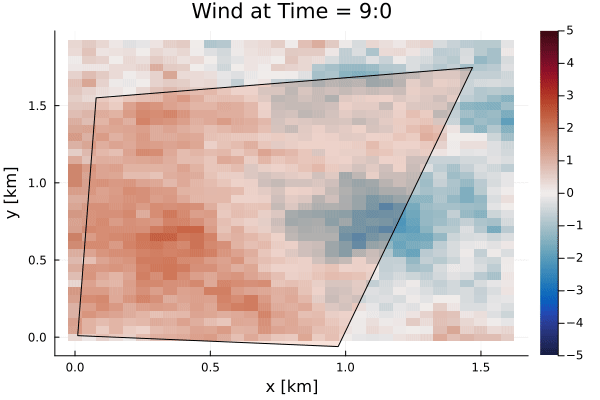

In [62]:
bounded_windfield = @animate for time_idx in 1:100:length(synthetic_data.ts)
    heatmap(synthetic_data.xs, synthetic_data.ys, synthetic_data.data[:, :, time_idx]', clims=(-5,5), cmap=:balance, plottype=:wx)
    polygon_vertices = hcat(JordanLakeDomain.convex_polygon.vertices, JordanLakeDomain.convex_polygon.vertices[:, 1])  # Close the polygon
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="")
    title!("Wind at Time = $(Int(floor(ts_hrs[time_idx]))):$(Int(floor(mod(ts_hrs[time_idx],1)*60)))")
    xlabel!("x [km]")
    ylabel!("y [km]")
    # plot!(aspect_ratio=:equal)
end
gif(bounded_windfield)

# Known Hyperparameter Simulation

## Controller Setup

In [63]:
# Create STGPKF Problem
problem = STGPKFProblem(grid_pts, ks, kt, dt_min)
kern = ks
ngp_grid_x = synthetic_data.xs
ngp_grid_y = synthetic_data.ys
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

# ASV Start Location
x0s = [@SVector[0.75, 0.75] for i=1:1]

1-element Vector{SVector{2, Float64}}:
 [0.75, 0.75]

In [64]:
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(xs), length(ys)
target_q_mat = ones(Nx, Ny)
target_q_mat *= 0.0

x_domain = xs
y_domain = ys

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if p ∈ JordanLakeDomain.convex_polygon.polygon
            target_q_mat[i, j] = 0.95
        end
    end
end

In [65]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(Δt)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [66]:
function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end


C_ = Cfun(0,0)
R_ = Rfun(0,0)

k = (C_^2 / R_)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end

Clarity_delta_new (generic function with 1 method)

In [67]:

function ergo_controller_weighted_2(t, xs, Mean, w_rated_val, convex_polygon;
    ergo_grid,
    ergo_q_map,
    traj,
    umax= 0.15, #30.0 * 60 / 1000,
    ΔT,
    kwargs...
    )
    
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(synthetic_data.xs), length(synthetic_data.ys)
w_rated = ones(Nx, Ny)
w_rated *= w_rated_val

#   Compute the target matrix 
lambda_param = 0.25
delta = -lambda_param*((Mean - w_rated).^2)
q_target_temp = target_q*(exp.(delta)) 


# Mask the matrix such that q_target is zero outisde the domain
# x_domain = range(0, 1.4, length=Nx)
# y_domain = range(0, 6.5, length=Ny)
x_domain = synthetic_data.xs
y_domain = synthetic_data.ys

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if (p ∈ convex_polygon.polygon) == false
            q_target_temp[i, j] = 0.0
        end
    end
end

# Get it in the right shape
q_target_itp = linear_interpolation((x_domain, y_domain), q_target_temp, extrapolation_bc=Interpolations.Line())
q_target_weighted = q_target_itp(ErgodicController.xs(ergo_grid), ErgodicController.ys(ergo_grid))     


target_spatial_dist = zeros(size(ergo_q_map))
Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))      

for i in CartesianIndices(target_spatial_dist)
    if q_target_weighted[i] > ergo_q_map[i]
#             println("here in first cond")
        target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], q_target_weighted[i])
    else
        target_spatial_dist[i] = 0.0
    end
end
    
u = [ErgodicController.controller_single_integrator_cvx_bound(ergo_grid, x, traj, target_spatial_dist, convex_polygon; umax=umax, do_boundary_correction=true) for x in xs]

#     println(u)

return u, q_target_temp

end

ergo_controllers_weighted_2 = [ergo_controller_weighted_2 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller_weighted_2)}:
 ergo_controller_weighted_2 (generic function with 1 method)

## Generate SOC Target Profile

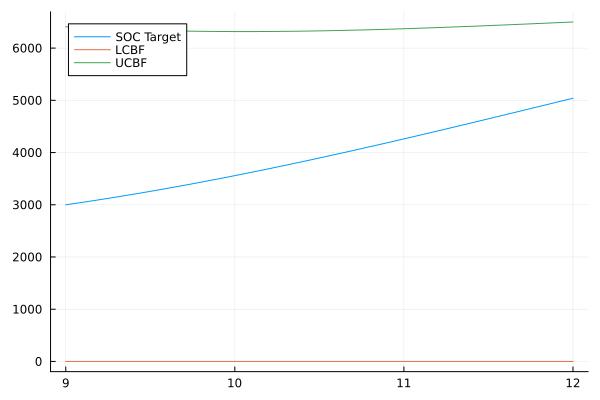

In [68]:
# Generate SOC_Target Profile
soc_begin = 3000
soc_end = 5000
lcbf = SoCController.compute_lcbf(ts_hrs, dt_hrs);
ucbf = SoCController.compute_ucbf(ts_hrs, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts_hrs, dt_hrs);
plot(ts_hrs, soc_target, label="SOC Target")
plot!(ts_hrs, lcbf, label="LCBF")
plot!(ts_hrs,ucbf, label="UCBF")

## Simulate

In [69]:
fuse_measurements_every_ΔT = 5.0/(60) # hours
recompute_controller_every_ΔT = 5.0 / (120.0*60) # minutes
# σ_t = zeros(15, 66);
# σ_t = zeros(66, 15);
σ_t = zeros(length(xs), length(ys));

w_rated_val = 0.0

@time res_ergo_hp =  SimulatorST.simulate_stationary(ts_min, x0s, soc_begin, ergo_controller_weighted_2, soc_target, w_rated_val, JordanLakeDomain.convex_polygon, problem; 
    ngpkf_grid=ngpkf_grid, 
    EnvData=synthetic_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|                                         |  ETA: N/A
Progress:   1%|▎                                        |  ETA: 0:13:53
Progress:   1%|▍                                        |  ETA: 0:11:46
Progress:   2%|▋                                        |  ETA: 0:12:35
Progress:   2%|▉                                        |  ETA: 0:12:43
Progress:   3%|█                                        |  ETA: 0:12:01
Progress:   3%|█▎                                       |  ETA: 0:12:18
Progress:   4%|█▌                                       |  ETA: 0:11:53
Progress:   4%|█▋                                       |  ETA: 0:11:53
Progress:   5%|█▉                                       |  ETA: 0:11:44
Progress:   5%|██▏                                      |  ETA: 0:11:48
Progress:   6%|██▎                                      |  ETA: 0:11:29
Progress:   6%|██▌                                      |  ETA: 0:11:36
Progress:   7%|██▊                                      |  ETA: 0:11

731.149914 seconds (105.71 M allocations: 218.224 GiB, 15.13% gc time, 0.50% compilation time)


Main.SimulatorST.SimResultWeightedSpeed{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Matrix{Float64}}, Vector{Matrix{Float64}}}(540.0:0.041666666666666664:720.0, Vector{SVector{2, Float64}}[[[0.75, 0.75]], [[0.7499935750635867, 0.7499973645682088]], [[0.7499977865954968, 0.7500028861900369]], [[0.75000407182248, 0.7500058393629766]], [[0.7500103265640976, 0.7500088565663073]], [[0.7500165396719587, 0.7500119585977948]], [[0.7500225597136833, 0.750015420447918]], [[0.7500284106443286, 0.7500191610253101]], [[0.750033954211044, 0.750023343629369]], [[0.7500391673270416, 0.7500279315188879]]  …  [[0.7505524229104772, 0.7755741846348306]], [[0.7505515239961069, 0.7755810706541159]], [[0.750550624855752, 0.7755879566438969]], [[0.7505497314718523, 0.7755948433828821]], [[0.7505488378620703, 0.7756017

In [70]:
jldsave("20250506_stationary_lt45_ls75_sigt1_sigs1.jld2"; res_ergo_hp, synthetic_data, soc_target, ts_hrs, w_rated_val)